In [20]:
import pandas as pd
import numpy as np
import random
import math
import json
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
############################################################################################################################

In [ ]:
# Practical ML
# Classification
    # Logistic Regression
    # Random Forest
# Regression
    # Linear Regression
    # Random Forest

# EDA
# load the dataset (csv, txt, json)
# missing value
# outliers
# scatter plot between each dependent variable to the target
# histogram

# Building model
# feature selection based on the EDA
# missing value handling
# normalization when using linear or logistic regression
# one-hot encoding when using logistic regression
# hyperparameter tuning - cross-validation
# training, validation, testing
# learning curve: training, validation error vs. iterations or number of ensemble models

# evaluation
# making predictions on the testing set
# further directions of improving the model

In [2]:
############################################################################################################################

In [7]:
# regression problem

df = pd.read_csv('/Users/ganfeng/Documents/Job Application 2023/interview/Block/insurance.csv')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [12]:
# there is no missing value in the target
# if there is missing value, drop the rows withe missing target

target = 'charges'
df = df.dropna(subset=[target])

In [13]:
# Preparing features and target variable

X = df.drop(target, axis=1)
y = df[target]

In [14]:
# categorical feature
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [15]:
categorical_features

['sex', 'smoker', 'region']

In [17]:
# numerical feature
numerical_features = list(set(X.columns) - set(categorical_features))

In [18]:
numerical_features

['age', 'children', 'bmi']

In [57]:
# Check for missing values in the feature dataframe

missing_values = X.isnull().sum()

In [19]:
# there is no missing value in this specific dataset
# if there is, check the percentage
# if percentage is large, say greater than 30%, drop the column
# if percentage is small, use mean to impute numerical, use mode to input categorical

# example:
# the reason for mode()[0] here is because there might have multiple modes
# inplace means modify the existing dataframe instead of create a new dataframe
X['age'].fillna(X['age'].mean(), inplace=True)
X['sex'].fillna(X['sex'].mode()[0], inplace=True)

/var/folders/vt/p3vf9d352l7fsw1fclffgfsh0000gn/T/ipykernel_43202/1131100710.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['age'].fillna(X['age'].mean(), inplace=True)
/var/folders/vt/p3vf9d352l7fsw1fclffgfsh0000gn/T/ipykernel_43202/1131100710.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alway

In [ ]:
# Check for outliers in numerical columns
# For simplicity, we'll use the Interquartile Range (IQR) method to flag any values that fall outside of 1.5 * IQR
# This is a common method but keep in mind it's not the only one and not always the best depending on the data distribution

'''
numerical_columns = ['age', 'bmi', 'children', 'charges']
outliers = {}

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    
    outliers[col] = df.loc[(df[col] < lower_bound) | (df[col] > upper_bound), col]

# Initial assessment of missing values and outliers
missing_values, {key: len(value) for key, value in outliers.items()}
'''

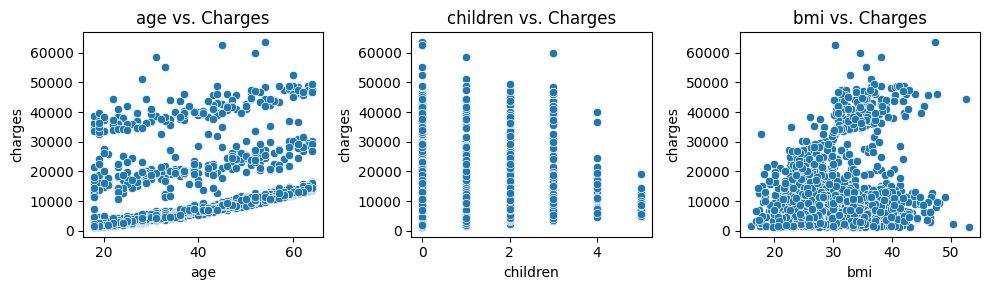

In [24]:
# Creating scatter plots for numerical predictors vs. charges
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for ax, predictor in zip(axes, numerical_features):
    sns.scatterplot(data=df, x=predictor, y='charges', ax=ax)
    ax.set_title(f'{predictor} vs. Charges')

plt.tight_layout()
plt.show()

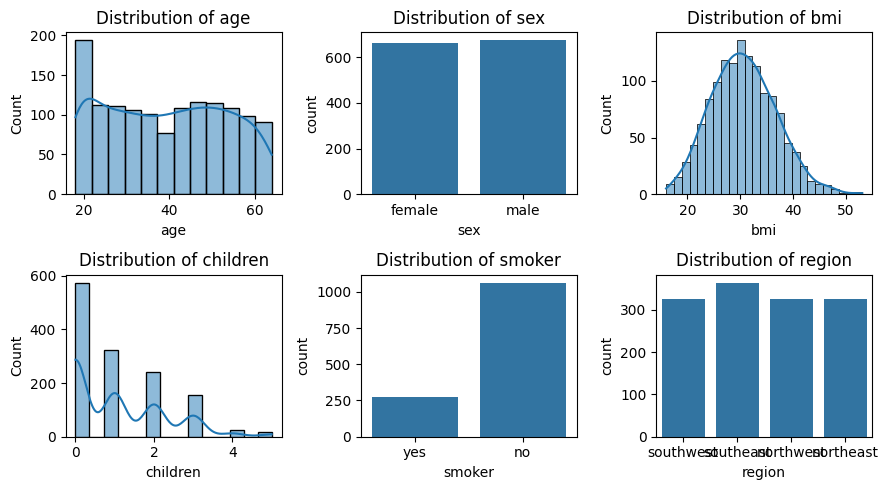

In [25]:
# Creating histograms for all predictors including the categorical ones to understand their distributions
fig, axes = plt.subplots(2, 3, figsize=(9, 5))
predictors = list(X.columns)

for ax, predictor in zip(axes.flatten(), predictors):
    if predictor in categorical_features:
        sns.countplot(data=df, x=predictor, ax=ax)
    else:
        sns.histplot(data=df, x=predictor, kde=True, ax=ax)
    ax.set_title(f'Distribution of {predictor}')

plt.tight_layout()
plt.show()

In [ ]:
############################################################################################################################

In [26]:
# linear regression model
# drop_first is to reduce multicollinearity
X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

scaler = StandardScaler() # (x-mu)/std
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)

mse

33596915.85136149

In [ ]:
############################################################################################################################

In [27]:
# random forest model
# for random forest in sklearn, need to conduct one-hot encoding

rf_model = RandomForestRegressor(n_estimators=200, max_depth=2, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)

mse_rf

24571879.805021804

In [36]:
# Get feature importances from the model
feature_importances = rf_model.feature_importances_
feature_names = X_train.columns

importance_arr = []

for i in range(len(feature_importances)):
    importance_arr.append((feature_names[i], feature_importances[i]))

sorted(importance_arr, key=lambda x: x[1], reverse=True)

[('smoker_yes', 0.7366048171831255),
 ('bmi', 0.18359920160971635),
 ('age', 0.07979598120715803),
 ('children', 0.0),
 ('sex_male', 0.0),
 ('region_northwest', 0.0),
 ('region_southeast', 0.0),
 ('region_southwest', 0.0)]

In [37]:
# grid search cross validation
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [50, 100, 200, 500],'max_depth': [2, 5, 10]}

grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                           param_grid=param_grid,
                           scoring='neg_mean_squared_error',
                           cv=5,
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

best_params, best_score

({'max_depth': 5, 'n_estimators': 500}, -21945320.096634295)

In [ ]:
############################################################################################################################

In [41]:
# classification problem
df = pd.read_csv('/Users/ganfeng/Documents/Job Application 2023/interview/Block/loan.csv')
df = df.drop('Loan_ID', axis=1)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             376 non-null    object 
 1   Married            381 non-null    object 
 2   Dependents         373 non-null    object 
 3   Education          381 non-null    object 
 4   Self_Employed      360 non-null    object 
 5   ApplicantIncome    381 non-null    int64  
 6   CoapplicantIncome  381 non-null    float64
 7   LoanAmount         381 non-null    float64
 8   Loan_Amount_Term   370 non-null    float64
 9   Credit_History     351 non-null    float64
 10  Property_Area      381 non-null    object 
 11  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 35.8+ KB


In [43]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,381.000000,381.000000,381.000000,370.000000,351.000000
mean,3579.845144,1277.275381,104.986877,340.864865,0.837607
std,1419.813818,2340.818114,28.358464,68.549257,0.369338
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2600.000000,0.000000,90.000000,360.000000,1.000000
50%,3333.000000,983.000000,110.000000,360.000000,1.000000
75%,4288.000000,2016.000000,127.000000,360.000000,1.000000
max,9703.000000,33837.000000,150.000000,480.000000,1.000000


In [44]:
df_null_cnt = pd.DataFrame(df.isnull().sum())
df_null_cnt = df_null_cnt.reset_index()
df_null_cnt.columns = ['feature', 'null_count']
drop_list = list(df_null_cnt[df_null_cnt['null_count']>0]['feature'])

In [45]:
drop_list

['Gender', 'Dependents', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History']

In [46]:
df = df.dropna(subset=drop_list)

In [47]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
376,Male,Yes,3+,Graduate,No,5703,0.0,128.0,360.0,1.0,Urban,Y
377,Male,Yes,0,Graduate,No,3232,1950.0,108.0,360.0,1.0,Rural,Y
378,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
379,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y


In [51]:
target = 'Loan_Status'
X = df.drop(target, axis=1)
y = df[target]

In [52]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [53]:
############################################################################################################################

In [54]:
# logistic regression

scaler = StandardScaler()
X_encoded_scaled = scaler.fit_transform(X_encoded)
X_train, X_test, y_train, y_test = train_test_split(X_encoded_scaled, y, test_size=0.2, random_state=42)

In [55]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [56]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:,1]
roc_auc_score(y_test, y_pred_proba)

0.7988095238095237

In [ ]:
############################################################################################################################

In [57]:
# Random forest classification
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_y_pred = rf_model.predict(X_test)
rf_y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

rf_auc_score = roc_auc_score(y_test, rf_y_pred_proba)
rf_auc_score

0.8220238095238095

In [ ]:
############################################################################################################################

In [ ]:
# load files in different formats in Python
# read csv
df_insurance = pd.read_csv('/Users/ganfeng/Documents/Job Application 2023/interview/Block/insurance.csv')
df_loan = pd.read_csv('/Users/ganfeng/Documents/Job Application 2023/interview/Block/loan.csv')

# read txt
df = pd.read_csv("txt_file.txt", sep=" ", header=None, names=["Team1", "Team2"])

# read json object
df = pd.read_json('data.json')

# read json string
# Example JSON string
json_string = '{"name": ["John", "Doe"], "age": [28, 34], "city": ["New York", "Chicago"]}'
# Load the JSON string into a pandas DataFrame
df_from_string = pd.read_json(json_string)
# Display the DataFrame
print(df_from_string)

# read json string as dictionary
# Example JSON string
json_string = '{"name": "John", "age": 30, "city": "New York"}'
# Parse the JSON string into a Python dictionary
data = json.loads(json_string)
# Display the dictionary
print(data)
# Accessing an element in the dictionary
print(data['name'])  # Output: John

In [29]:
# Given a sentence, making predictions using Markov Chain
# Predict the next word based on the frequency of the words in this sentence
# Similar to LC 528
from collections import Counter

sentence = "Hello, world! This is a test sentence; this sentence is just for testing, testing, and testing."
word_list = sentence.split()

filtered_word_list = []
for word in word_list:
    filtered_word_list.append(''.join(char.lower() for char in word if char.isalpha()))

word_count = dict(Counter(filtered_word_list))

total_word_num = len(filtered_word_list)
w = list(word_count.values())
word_arr = list(word_count.keys())


def markov_chain_pred_next_word(w, word_arr):
    cumsum = []
    curr = 0
    for weight in w:
        curr += weight
        cumsum.append(curr)
    total_weight = curr

    import random
    target = random.random()*total_weight
    
    left = 0
    right = len(cumsum)-1

    while left<=right:
        mid = (left+right)//2
        if cumsum[mid] == target:
            return word_arr[mid]
        elif cumsum[mid] > target:
            right = mid -1
        else:
            left = mid + 1
    return word_arr[left]


simulation_result = []
sim_num = 100000

results = []
for _ in range(sim_num):
    results.append(markov_chain_pred_next_word(w, word_arr))

Counter(results)

Counter({'testing': 18682,
         'sentence': 12699,
         'this': 12534,
         'is': 12437,
         'a': 6341,
         'and': 6298,
         'for': 6293,
         'just': 6206,
         'test': 6190,
         'hello': 6178,
         'world': 6142})

In [5]:
# given a string with multiple rows, each row is 'field: tag, tag, tag'
# 1. given a tag, find all the fields with this tag
# 2. given two tags [tag1, tag2], find all the fields with either tag1 or tag2
# 3. given two tags [tag1, tag2], find all the fields with both tag1 and tag2

from collections import defaultdict

def create_tag_dict(input):
    tags = defaultdict(list)
    splited_input = input.split('\n')

    for feature_tag_pair in splited_input:
        feature_tag_split = feature_tag_pair.split(': ')
        feature = feature_tag_split[0]
        for tag in feature_tag_split[1].split():
            tags[tag].append(feature)
    return dict(tags)

def find_one_tag(tag_feature_dict, tag):
    if tag in tag_feature_dict:
        return tag_feature_dict[tag]

def find_either_tag(tag_feature_dict, tags):
    seen = set()
    for t in tags:
        if t in tag_feature_dict:
            for feature in tag_feature_dict[t]:
                seen.add(feature)
    return list(seen)

def find_both_tag(tag_feature_dict, tags):
    result = []
    seen = defaultdict(int)
    for t in tags:
        if t in tag_feature_dict:
            for feature in tag_feature_dict[t]:
                seen[feature] += 1
    
    for key, value in seen.items():
        if value == len(tags):
            result.append(key)
    return result

In [8]:
input = "feature1: string categorical\nfeature2: numeric\nfeature3: numeric categorical\nfeature4: string splittable\nfeature5: string"
sample = create_tag_dict(input)

In [14]:
sample

{'string': ['feature1', 'feature4', 'feature5'],
 'categorical': ['feature1', 'feature3'],
 'numeric': ['feature2', 'feature3'],
 'splittable': ['feature4']}

In [9]:
find_one_tag(sample, 'string')

['feature1', 'feature4', 'feature5']

In [13]:
find_either_tag(sample, ["categorical", "splittable"])

['feature1', 'feature3', 'feature4']

In [10]:
find_both_tag(sample, ["categorical", "string"])

['feature1']

In [31]:
# execute commands in a string

def execute_commands(commands):
    variables = {}
    output = []

    for command in commands:
        parts = command.split()
        cmd_type = parts[0]
        if cmd_type == 'print':
            if parts[1].isdigit():
                output.append(parts[1])
            else:
                output.append(variables[parts[1]])
        elif cmd_type == 'LET':
            if parts[2].isdigit():
                variables[parts[1]] = parts[2]
            else:
                variables[parts[1]] = variables[parts[2]]
    return output


input1 = ['print 7', 'print 5']
input2 = ['LET a 5', 'LET b a', 'print a', 'print b']

output1 = execute_commands(input1)
output2 = execute_commands(input2)

print("Output 1:", output1)
print("Output 2:", output2)

Output 1: ['7', '5']
Output 2: ['5', '5']


In [24]:
# Convert the value in a JSON string to the key
# if there are multiple values for a key, put them in a python list
json_str = '{"name": "John", "age": 30, "city": "New York", "distance": 30}'
parsed_json = json.loads(json_str)

inverted_dict = {}

for key, value in parsed_json.items():
    # Check if the value already exists as a key in the inverted dictionary
    if value in inverted_dict:
        # If the existing value is not a list, convert it into a list
        if not isinstance(inverted_dict[value], list):
            inverted_dict[value] = [inverted_dict[value]]
        # Append the new key to the list
        inverted_dict[value].append(key)
    else:
        # If the value does not exist, add it to the inverted dictionary
        inverted_dict[value] = key

inverted_dict

{'John': 'name', 30: ['age', 'distance'], 'New York': 'city'}

In [32]:
# calculate the percentage of time that A has greater power than B

def calculate_percentage_time_greater_corrected(playerA, playerB, game_window):
    # Combine both players' power outputs and mark them for identification
    events = sorted([(t, p, 'A') for t, p in playerA] + [(t, p, 'B') for t, p in playerB], key=lambda x: x[0])
    
    # Add an initial event if the game doesn't start at 0
    if events[0][0] > 0:
        events.insert(0, (0, 0, 'start'))
    
    # Track the last power values and total time where A > B
    last_time = 0
    last_power_A = 0
    last_power_B = 0
    A_greater_time = 0
    
    for event in events:
        time, power, player = event
        
        # Update the time A was greater before processing the new event
        if last_power_A > last_power_B:
            A_greater_time += time - last_time
        
        # Update powers based on the current event
        if player == 'A':
            last_power_A = power
        elif player == 'B':
            last_power_B = power
        
        last_time = time
    
    # Handle the final segment if not handled yet
    if last_time < game_window and last_power_A > last_power_B:
        A_greater_time += game_window - last_time
    
    # Calculate and return the percentage
    return (A_greater_time/game_window) * 100

# Correcting the inputs based on the provided explanation
total_game_window = 300
player_A = [[50, 75], [100, 40], [200, 100]]
player_B = [[1, 70], [75, 80]]

# Calculate the percentage again with the corrected approach
percentage_corrected = calculate_percentage_time_greater_corrected(player_A, player_B, total_game_window)
percentage_corrected

41.66666666666667

In [4]:
# given a number n, count total occurences of 0, 2, and 4 in the list from [0, 1, 2, ..., n]
# example: n = 22, should return 11, this is because the count for 0, 2, and 4 are as {0:3, 2:6, 4:2}
def count_occurence(n):
    nums = np.arange(n+1)
    count = {}

    for num in nums:
        for char in str(num):
            if char in count:
                count[char] += 1
            elif char == '0' or char == '2' or char == '4':
                count[char] = 1
    return sum(list(count.values()))

count_occurence(22)

11

In [33]:
# find the peak in a array with minimum value
def find_minimal_peak(arr):
    min_peak = float('inf')
    min_idx = float('inf')

    if len(arr)==1:
        return [arr[0], 0]
    for i in range(len(arr)):
        if i==0:
            if arr[i]>arr[i+1] and arr[i]<min_peak:
                min_peak = arr[i]
                min_idx = i
        elif i == len(arr)-1:
            if arr[i]>arr[i-1] and arr[i]<min_peak:
                min_peak = arr[i]
                min_idx = i 
        else:
            if arr[i]>arr[i-1] and arr[i]>arr[i+1] and arr[i]<min_peak:
                min_peak = arr[i]
                min_idx = i
    return [min_peak, min_idx]


arr = [2, 7, 8, 5, 1, 6, 3, 9, 4]
result = []

while len(arr) != 0:
    min_peak = find_minimal_peak(arr)
    result.append(min_peak[0])
    arr.pop(min_peak[1])

result

[6, 8, 7, 5, 2, 9, 4, 3, 1]

In [1]:
# find all the combinations of two numbers in an array such that the summation two numbers is the power of 2.

def is_power_of_two(n):
    return n > 0 and (n & (n - 1)) == 0

def count_pairs_with_power_of_two_sum(nums):
    count = 0
    for i in range(len(nums)):
        for j in range(i+1, len(nums)):
            if is_power_of_two(nums[i] + nums[j]):
                count += 1
    return count

# Example usage
nums = [-1, 1, 0, 3]
count = count_pairs_with_power_of_two_sum(nums)
count

3

In [ ]:
# Simplify Path - LC71
def simplifyPath(path):
    components = path.split('/')
    stack = []

    for component in components:
        if component == '..':
            if stack:
                stack.pop()
        elif component and component != '.':
            stack.append(component)
    
    return '/' + '/'.join(stack)

In [ ]:
# given an array, and a target, return the combination of indices such that the summation of two numbers equal to the target

def sum_of_two(nums, target):
    nums.sort()
    pre = None
    result = []
    i = 0
    j = len(nums)-1

    while i<j:
        while nums[i]==pre:
            i+=1
        if nums[i]+nums[j]==target:
            result.append([nums[i], nums[j]])
            i+=1
            j-=1
            while nums[i]==nums[i-1] and i<j:
                i+=1
        elif nums[i]+nums[j]>target:
            j-=1
        else:
            i+=1
    return result


sum_of_two([1,1,2,3,4,5,6,7], 8)

In [ ]:
# Coupon recommendation
# Given a 'customer_matrix' with the information whether or not a customer enables the coupons
# Given a 'coupons' dictionary with the information of the coupons
# Given a function use to calculate the similarities between two customers
# For a given customer, find the top k similar customer and recommend the corresponding coupons

coupons = {0: 'McDonalds 10% off',
           1: 'Starbucks Free Coffee',
           2: 'Cat Backpack 20% off',
           3: 'Free Soda at Taco Bell',
           4: '$10 off for Skateboard'}

number_of_customer = 100
customer_matrix = []
dim = 5
for _ in range (number_of_customer) :
    customer_matrix.append(random.choices([0,1], k=dim))


customer_matrix_1 = customer_matrix.copy()
target_customer = [1, 0, 1, 0, 1]
def calculate_similarity(arr_1, arr_2):
    if arr_1 == [0]*dim or arr_2 == [0]*dim:
        return np.nan
    return (np.array(arr_1)*np.array(arr_2)).sum()/((np.sqrt((np.array(arr_1)**2).sum()))*(np.sqrt((np.array(arr_2)**2).sum())))


similarities = []
for i in range(len(customer_matrix_1)):
    sim = calculate_similarity(target_customer, customer_matrix_1[i])
    if math.isnan(sim)==False:
        similarities.append([i, sim])


similarities = sorted(similarities, key=lambda x:x[1], reverse=True) # default is smallest to largest
top_k = 10
idx = []
for i in range(top_k):
    idx.append(similarities[i][0])

In [ ]:
'''
from collections import defaultdict

class Solution:
    def __init__(self):
        self.tags_dict = defaultdict(list)
    
    def add(self, inp):
        strings = inp.split("\n")
        for string in strings:
            s = string.split(" : ")
            tag = s[1].split(" ")
            for t in tag:
                self.tags_dict[t].append(s[0])
        return self.tags_dict
    
    def find_one_feature(self, tag):
        if tag in self.tags_dict:
            return self.tags_dict[tag]
    
    def find_either_feature(self, tag):
        res = []
        seen = set()
        for t in tag:
            if t in self.tags_dict:
                for value in self.tags_dict[t]:
                    if value not in seen:
                        res.append(value)
                        seen.add(value)
        return res
    
    def find_both_feature(self, tag):
        res = []
        seen = defaultdict(int)
        for t in tag:
            if t in self.tags_dict:
                for value in self.tags_dict[t]:
                        seen[value] += 1
        for k,v in seen.items():
            if v == len(tag):
                res.append(k)
        return res
    

s = Solution()
input = "feature1 : string categorical\nfeature2 : numeric\nfeature3 : numeric categorical\nfeature4 : string splittable\nfeature5 : string"
print(s.add(input))
print(s.find_one_feature("string"))
print(s.find_either_feature(["categorical", "splittable"]))
print(s.find_both_feature(["categorical", "string"]))
'''